In [ ]:
#k1

import sys, time, os, json, sqlite3, gc
import pandas as pd, numpy as np, psutil

for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s} : {mod.__version__}")
    except ImportError:
        print(f"{nama:11s} : BELUM TERPASANG")

from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

# Dipakai kembali dari Praktikum 1 / K-3
proses = psutil.Process(os.getpid())
catatan = []

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil = fungsi()
    detik = time.perf_counter() - t0
    catatan.append({"langkah": label, "detik": round(detik, 2),
                    "delta_rss_mb": round(rss_mb() - m0, 1)})
    print(f"[{label}] {detik:.2f} s")
    return hasil

# --Baru di Praktikum 3: catatan asal-usul data (lineage)
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber": nama, "asal": asal,
        "diambil_pada": pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris": jumlah_baris, "keterangan": keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris")

pandas      : 2.2.3
numpy       : 2.1.3
pyarrow     : 23.0.1
requests    : 2.32.4
sklearn     : 1.6.1
sqlalchemy  : 2.0.54
Mounted at /content/drive


Tahap persiapan lingkungan kerja diawali dengan pengecekan versi pustaka esensial dan integrasi ruang penyimpanan Google Drive untuk membangun struktur direktori data secara terpusat. Selanjutnya, fungsi utilitas pemantauan konsumsi memori dan waktu eksekusi disiapkan untuk mengukur efisiensi komputasi dari setiap proses yang akan berjalan. Pada tahap ini juga mulai diimplementasikan mekanisme pencatatan asal-usul data guna melacak histori metrik dan sumber informasi dari setiap dataset yang digunakan selama praktikum.

In [ ]:
#k2

import requests, shutil

def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print("cache ditemukan:", os.path.basename(tujuan))
        return tujuan
    sementara = tujuan + ".part"
    for i in range(percobaan):
        try:
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    # Menggantikan shutil.copyfileobj agar GZIP otomatis didekompresi
                    for chunk in r.iter_content(chunk_size=8192):
                        if chunk:
                            f.write(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan) # atomik
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2**i) # exponential backoff
            print(f"percobaan {i+1} gagal ({e}); menunggu {jeda}s")
            time.sleep(jeda)
    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")

URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")

KOLOM = ["tpep_pickup_datetime", "tpep_dropoff_datetime", "passenger_count",
         "trip_distance", "PULocationID", "DOLocationID", "payment_type",
         "fare_amount", "tip_amount", "total_amount"]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC")
catat_sumber("zona", URL_ZONA, len(zona), "tabel dimensi 265 zona")
zona.head()

[unduh trip] 0.35 s
[unduh zona] 0.05 s
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB
[baca trip] 1.03 s
[lineage] trip: 3,066,766 baris
[lineage] zona: 265 baris


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


Proses pengunduhan dataset dilakukan melalui fungsi kustom yang memiliki mekanisme percobaan ulang dan penulisan atomik guna menjaga integritas file dari kemungkinan gagal unduh. Setelah dataset perjalanan taksi berformat Parquet dan tabel referensi wilayah berhasil disimpan, data tersebut langsung dimuat ke dalam Pandas dengan membatasi kolom yang ditarik agar alokasi memori berjalan lebih efisien. Tahapan pengumpulan data ini kemudian ditutup dengan mencatat jumlah baris serta metadata sumber ke dalam log pemantauan sebelum melakukan inspeksi awal pada tabel wilayah.

In [ ]:
#k3

API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    parameter = {
        "latitude": lat, "longitude": lon,
        "start_date": mulai, "end_date": selesai,
        "hourly": "temperature_2m,precipitation",
        "timezone": "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data: #validasi struktur
                raise ValueError("kunci 'hourly' tidak ada pada respons")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503): # layak dicoba ulang
            time.sleep(2**i)
            continue
        r.raise_for_status()
        #galat lain: hentikan
        raise RuntimeError("API cuaca tidak merespons dengan benar")

cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))

cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={"time": "jam_mulai",
                              "temperature_2m": "suhu_c",
                              "precipitation": "hujan_mm"})

catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive")
cuaca.head()

[ambil cuaca] 0.49 s
[lineage] cuaca: 744 baris


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


Pengumpulan data cuaca historis dilakukan melalui pemanggilan Open-Meteo API dengan menyertakan parameter koordinat lokasi dan rentang waktu secara spesifik. Fungsi penarikan data ini telah mengimplementasikan mekanisme *retry* bersyarat untuk mengantisipasi gangguan server maupun pembatasan *request* dari penyedia layanan. Setelah respons API berhasil dimuat ke dalam *dataframe*, tahap selanjutnya adalah melakukan standardisasi tipe data waktu dan merapikan nama kolom sebelum keseluruhan informasi tersebut direkam ke dalam log pemantauan.

In [ ]:
#k4

def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
    jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c": np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm": np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

# Pakai hanya jika K-3 gagal:
# cuaca = cuaca_sintetis()
# catat_sumber("cuaca", "sintetis", len(cuaca), "PENGGANTI bukan data nyata")

Sebagai langkah antisipasi kegagalan penarikan data dari API, sebuah fungsi generator disiapkan untuk membangun dataset cuaca sintetis dalam rentang waktu per jam. Pembuatan data cadangan ini memanfaatkan distribusi normal untuk menyimulasikan nilai suhu dan distribusi gamma untuk menghasilkan angka curah hujan acak yang terkontrol. Apabila data riil sama sekali tidak dapat diakses, dataset buatan ini akan diaktifkan dan dicatat ke dalam log pemantauan dengan label penanda khusus agar riwayat asal-usul data tetap terorganisasi dengan baik.

In [ ]:
#k5

from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine = create_engine(f"sqlite:///{PATH_DB}")

tarif_referensi = pd.DataFrame({
    "payment_type": [1, 2, 3, 4, 5, 6],
    "nama_pembayaran": ["Kartu kredit", "Tunai", "Gratis",
                        "Sengketa", "Tidak diketahui", "Perjalanan batal"],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# tabel transaksi tiruan untuk latihan pembacaan bertahap
trip.head(300_000).to_sql("trip_operasional", engine, if_exists="replace", index=False, chunksize=50_000)

print("Tabel dibuat:", pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", engine)["name"].tolist())

SQL = """
SELECT payment_type, COUNT(*) AS jumlah, AVG(total_amount) AS rata_total
FROM trip_operasional
WHERE total_amount > 0
GROUP BY payment_type
ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print(ringkas_db)

# Pembacaan bertahap: agregasi tanpa memuat seluruh tabel ke memori
total_baris = 0
for bagian in pd.read_sql("SELECT trip_distance FROM trip_operasional", engine, chunksize=50_000):
    total_baris += len(bagian)
print("dibaca bertahap:", f"{total_baris:,}", "baris")

tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber("tarif_referensi", PATH_DB, len(tarif_referensi), "tabel dimensi dari basis data operasional")

Tabel dibuat: ['tarif_referensi', 'trip_operasional']
   payment_type  jumlah  rata_total
0             1  226967   31.339172
1             2   66504   25.218836
2             4    2082   26.611114
3             3    1553   22.089691
dibaca bertahap: 300,000 baris
[lineage] tarif_referensi: 6 baris


Integrasi basis data operasional disimulasikan menggunakan SQLite dan SQLAlchemy untuk membangun tabel referensi tarif beserta sebagian riwayat perjalanan taksi. Evaluasi awal terhadap profil metode pembayaran dieksekusi secara langsung melalui kueri SQL agar proses agregasi berjalan lebih efisien di tingkat basis data. Selain itu, teknik pembacaan data secara bertahap juga dipraktikkan guna mencegah lonjakan konsumsi memori saat sistem harus mengekstraksi data dalam jumlah yang masif.

In [ ]:
#k6

trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom": kol, "tipe": str(s.dtype),
            "persen_hilang": round(100 * s.isna().mean(), 3),
            "nilai_unik": s.nunique(dropna=True),
            "contoh": s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
profil

AWAL, AKHIR = pd.Timestamp("2023-01-01"), pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    "kelengkapan: passenger_count ada": trip["passenger_count"].notna(),
    "keunikan: baris tidak duplikat": ~trip.duplicated(),
    "validitas: jarak 0-100 mil": trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0": trip["total_amount"] > 0,
    "validitas: PULocationID dikenal": trip["PULocationID"].isin(zona_sah),
    "konsistensi: durasi 1-180 menit": trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare": trip["total_amount"] >= trip["fare_amount"],
    "ketepatan waktu dalam Jan 2023": trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {"aturan": nama, "lulus": int(mask.sum()), "gagal": int((~mask).sum()),
     "persen_gagal": round(100 * (~mask).mean(), 3)}
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False)

laporan

,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
2,validitas: jarak 0-100 mil,3020816,45950,1.498
5,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
6,konsistensi: total >= fare,3041743,25023,0.816
7,ketepatan waktu dalam Jan 2023,3066718,48,0.002
1,keunikan: baris tidak duplikat,3066766,0,0.000
4,validitas: PULocationID dikenal,3066766,0,0.000


Tahap pemrofilan data diawali dengan kalkulasi durasi perjalanan dalam satuan menit yang diekstrak langsung dari atribut waktu penjemputan dan penurunan. Setelah itu, struktur dataset diinspeksi secara terprogram untuk memetakan metadata krusial seperti tipe data dan tingkat kekosongan nilai pada masing-masing kolom. Keseluruhan data kemudian dievaluasi secara ketat menggunakan serangkaian aturan kualitas yang mencakup aspek kelengkapan informasi, keunikan baris, batas logis operasional, hingga validitas kode wilayah taksi. Seluruh hasil pengujian kualitas tersebut akhirnya dirangkum ke dalam sebuah matriks evaluasi agar persentase anomali pada setiap metrik dapat diidentifikasi secara jelas.

In [ ]:
#k7

KOL = "passenger_count"
asli = trip[KOL]
print("persen hilang:", round(100 * asli.isna().mean(), 3))

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour
strategi = {
    "1_dibuang": asli.dropna(),
    "2_isi_median": asli.fillna(asli.median()),
    "3_isi_modus": asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam": asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {"strategi": nama, "n": len(s), "mean": round(s.mean(), 4),
     "median": s.median(), "std": round(s.std(), 4)}
    for nama, s in strategi.items()
])
banding

# Strategi yang dipilih modul ini: tandai + isi per kelompok (lihat G.4)
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(trip.groupby("jam")[KOL].transform("median"))
trip[KOL] = trip[KOL].fillna(trip[KOL].median()) # jaring pengaman

# Duplikat: periksa dua tingkat
dup_penuh = trip.duplicated().sum()
KUNCI = ["tpep_pickup_datetime", "tpep_dropoff_datetime",
         "PULocationID", "DOLocationID", "total_amount"]
dup_kunci = trip.duplicated(subset=KUNCI).sum()
print(f"duplikat penuh: {dup_penuh:,} | duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"{sebelum:,} -> {len(trip):,} baris")

persen hilang: 2.339
duplikat penuh: 0 | duplikat pada kunci: 1
3,066,766 -> 3,066,765 baris


Penanganan *missing value* pada variabel jumlah penumpang dilakukan dengan membandingkan beberapa metode imputasi terlebih dahulu guna mengevaluasi perubahan distribusi statistiknya. Pengisian nilai kosong tersebut pada akhirnya dikerjakan menggunakan nilai median dari masing-masing jam penjemputan, yang juga diikuti dengan pembuatan kolom indikator baru untuk menandai rekam jejak data hasil imputasi. Rangkaian prapemrosesan ini kemudian ditutup dengan eliminasi baris duplikat secara spesifik menggunakan kombinasi parameter waktu, lokasi, dan tarif perjalanan untuk memastikan ketunggalan setiap observasi.

In [ ]:
#k8

def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z = (s - s.mean()) / s.std()
        hasil.append({
            "kolom": kol, "batas_bawah": round(lo, 2), "batas_atas": round(hi, 2),
            "outlier_iqr": int(((s < lo) | (s > hi)).sum()),
            "outlier_z3": int((z.abs() > 3).sum()), "p99": round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])

# Tindakan berbeda untuk maksud berbeda (lihat G.5)
layak = (trip["trip_distance"].between(0.01, 100)
         & trip["durasi_menit"].between(1, 180)
         & (trip["total_amount"] > 0))
bersih = trip.loc[layak].copy()

# tandai, jangan buang: outlier bisa jadi memang kenyataan bisnis
lo, hi = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi).astype("int8")

# winsorizing hanya untuk kolom turunan yang akan dipakai model
batas_atas = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas)

print(f"{len(trip):,} -> {len(bersih):,} baris "
      f"({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")

# Join 1: tabel zona (dimensi)
print("kunci zona unik?", zona["LocationID"].is_unique) # WAJIB diperiksa
n0 = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on="PULocationID", right_on="LocationID",
    how="left", validate="many_to_one")
bersih = bersih.drop(columns="LocationID")

# gagal keras bila tidak 1:1
print(f"baris {n0:,} -> {len(bersih):,} (harus sama)")
print("zona tak dikenal:", bersih["zona_naik"].isna().sum())

# Join 2: tabel pembayaran dari basis data
bersih = bersih.merge(tarif_referensi[["payment_type", "nama_pembayaran"]],
                      on="payment_type", how="left", validate="many_to_one")

# Join 3: cuaca, berdasarkan jam (tingkat rincian harus disamakan dulu)
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0 = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"baris {n0:,} -> {len(bersih):,}")
print("tanpa data cuaca:", bersih["suhu_c"].isna().sum())

3,066,765 -> 2,986,910 baris (2.60% dibuang)
kunci zona unik? True
baris 2,986,910 -> 2,986,910 (harus sama)
zona tak dikenal: 37609
baris 2,986,910 -> 2,986,910
tanpa data cuaca: 37


Identifikasi nilai ekstrem dilakukan menggunakan perhitungan Interquartile Range untuk menyaring anomali operasional pada atribut jarak, durasi, serta tarif perjalanan taksi. Observasi ekstrem yang berpotensi valid secara bisnis tetap dipertahankan melalui pemberian label khusus, sedangkan variabel jarak dipotong pada batas persentil atas sebagai bentuk penyesuaian awal untuk pemodelan data. Dataset bersih tersebut selanjutnya diperkaya informasinya dengan melakukan tiga kali operasi *left join* untuk mengintegrasikan tabel dimensi wilayah penjemputan, referensi tipe pembayaran, dan data cuaca historis berdasarkan jam keberangkatan.

In [ ]:
#k9

bersih["hari_minggu"] = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"] = (bersih["hari_minggu"] >= 5).astype("int8")

bersih["kecepatan_mph"] = (bersih["trip_distance"] / (bersih["durasi_menit"] / 60)).round(2)
bersih["tarif_per_mil"] = (bersih["total_amount"] / bersih["trip_distance"]).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder

FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42)

latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)

skala = StandardScaler().fit(latih[FITUR_NUM]) # fit HANYA di data latih
latih_num = skala.transform(latih[FITUR_NUM])
uji_num = skala.transform(uji[FITUR_NUM]) # transform saja, tanpa fit ulang

print("mean latih (harus ~0):", latih_num.mean(axis=0).round(3))
print("mean uji (tidak harus 0):", uji_num.mean(axis=0).round(3))

# Bergantung versi: parameter sparse_output ada sejak scikit-learn 1.2
enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])

print("jumlah kolom hasil one-hot:", latih_kat.shape[1])
print("nama kolom:", enc.get_feature_names_out()[:6], "...")

mean latih (harus ~0): [-0.  0. -0.]
mean uji (tidak harus 0): [ 0.001  0.001 -0.009]
jumlah kolom hasil one-hot: 11
nama kolom: ['nama_pembayaran_Gratis' 'nama_pembayaran_Kartu kredit'
 'nama_pembayaran_Sengketa' 'nama_pembayaran_Tunai' 'borough_naik_Bronx'
 'borough_naik_Brooklyn'] ...


Tahap rekayasa fitur difokuskan pada ekstraksi variabel turunan baru seperti status akhir pekan, kecepatan kendaraan, metrik tarif per mil, dan indikator cuaca hujan untuk memperkaya atribut analitis. Setelah mengambil sampel data acak yang bebas dari nilai kosong, dataset langsung dipecah menjadi bagian pelatihan dan pengujian guna menghindari kebocoran informasi ke depannya. Persiapan pemodelan ini diakhiri dengan standardisasi skala pada fitur numerik yang di-fit secara eksklusif pada data latih, serta penerapan *one-hot encoding* untuk memetakan variabel kategorik ke dalam bentuk matriks numerik.

In [ ]:
#k10

KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]", "trip_distance": "float64",
    "durasi_menit": "float64", "total_amount": "float64",
    "borough_naik": "object", "nama_pembayaran": "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe {kol}: {df[kol].dtype} != {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"Validasi lulus: {len(df):,} baris x {df.shape[1]} kolom")
    return df

validasi(bersih)

def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Satu fungsi, idempoten: input mentah -> DataFrame tervalidasi."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z = pd.read_csv(path_zona)

    df["durasi_menit"] = ((df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
                          .dt.total_seconds() / 60)
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median"))
    df = df.drop_duplicates(subset=KUNCI)

    df = df[df["trip_distance"].between(0.01, 100)
            & df["durasi_menit"].between(1, 180)
            & (df["total_amount"] > 0)]

    df = (df.merge(z[["LocationID", "Borough"]]
                   .rename(columns={"Borough": "borough_naik"}),
                   left_on="PULocationID", right_on="LocationID",
                   how="left", validate="many_to_one")
          .drop(columns="LocationID")
          .merge(df_tarif[["payment_type", "nama_pembayaran"]],
                 on="payment_type", how="left", validate="many_to_one"))

    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))

OUT = os.path.join(DIR_KURASI, "trips_bersih")
hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)

ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False))
print("partisi yang terbentuk:", sorted(os.listdir(OUT))[5], "...")

# Bukti idempotensi: jalankan ulang, hasil harus identik
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print("idempoten?", len(ulang) == len(hasil))

# Artefak yang dikumpulkan
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

Validasi lulus: 2,986,910 baris x 26 kolom
Validasi lulus: 2,986,910 baris x 17 kolom
[pipeline penuh] 5.88 s
[tulis parquet berpartisi] 3.55 s
partisi yang terbentuk: borough_naik=Staten%20Island ...
Validasi lulus: 2,986,910 baris x 17 kolom
idempoten? True


'/content/drive/MyDrive/BigData/Praktikum3/trips_bersih.zip'

Seluruh proses transformasi data kemudian disatukan ke dalam sebuah fungsi pipeline yang idempoten agar alur pembersihan dari tahap pembacaan berkas mentah hingga tervalidasi dapat dieksekusi secara konsisten. Mekanisme validasi akhir diterapkan secara terprogram menggunakan parameter kontrak struktur data untuk menjamin kecocokan tipe kolom dan ketiadaan observasi duplikat sebelum tahap penyimpanan. Dataset bersih yang telah lolos uji tersebut akhirnya diekspor ke format Parquet dengan pembagian partisi berdasarkan wilayah penjemputan, disusul dengan pengarsipan seluruh artefak pendukung seperti metrik kinerja dan laporan kualitas sebagai luaran akhir praktikum.

In [ ]:
#k11

!pip install -q pyspark==3.5.1

from pyspark.sql import SparkSession, functions as F

spark = (SparkSession.builder.appName("BD-P02").master("local[*]")
         .config("spark.driver.memory", "4g")
         .config("spark.sql.shuffle.partitions", "8")
         .getOrCreate())
spark.sparkContext.setLogLevel("WARN")

sdf = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (sdf
    .withColumn("durasi_menit",
                (F.unix_timestamp("tpep_dropoff_datetime")
                 - F.unix_timestamp("tpep_pickup_datetime")) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(F.broadcast(szona), # tabel kecil: broadcast
          sdf.PULocationID == szona.LocationID, "left")
    .drop("LocationID"))

ukur("spark: hitung baris bersih", lambda: sbersih.count())
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

sbersih.explain() # cari BroadcastHashJoin, bukan SortMergeJoin
spark.stop()

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 1.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 7.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.
[spark: hitung baris bersih] 17.22 s
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

== Physical Plan ==
AdaptiveSparkPlan isFinalPlan=false
+- Project [tpep_pickup_datetime#1, tpep_dropoff_datetime#2, passenger_count#245, trip_distance#247, PULocationID#7L, DOLocation

Pengolahan data skala besar pada tahap akhir praktikum ini dieksekusi menggunakan lingkungan kerja PySpark yang diawali dengan penyesuaian konfigurasi memori dan jumlah partisi agar komputasi berjalan optimal. Tahap prapemrosesan kembali menerapkan logika kalkulasi durasi, penyaringan nilai anomali, serta eliminasi duplikat, yang langsung diintegrasikan dengan tabel wilayah penjemputan menggunakan strategi *broadcast join* untuk meminimalkan beban pergerakan data. Rangkaian pengolahan ini ditutup dengan memverifikasi rencana eksekusi sistem untuk memastikan efisiensi *join*, menampilkan hasil agregasi wilayah terbanyak, lalu menyimpan dataset bersih tersebut ke dalam format Parquet yang terpartisi.

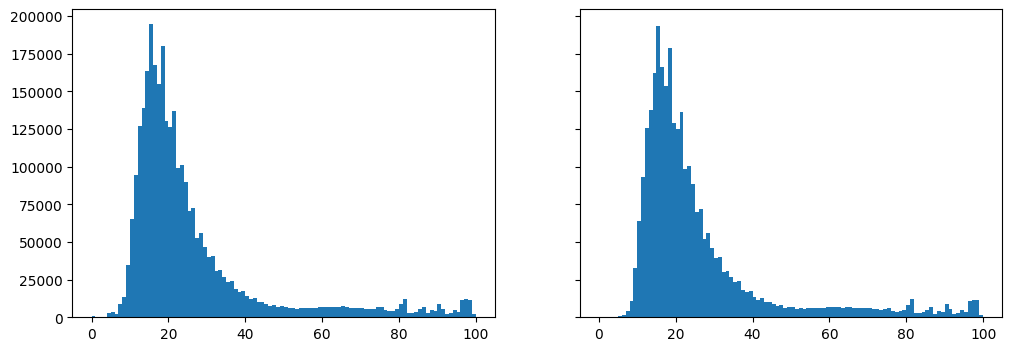

In [ ]:
# analisis hasil

import matplotlib.pyplot as plt

trip_awal = pd.read_parquet(PATH_TRIP, columns=["total_amount"])
fig, ax = plt.subplots(1,2, figsize=(12,4), sharex=True, sharey=True)
ax[0].hist(trip_awal["total_amount"], bins=100, range=(0,100))
ax[1].hist(bersih["total_amount"], bins=100, range=(0,100))
plt.savefig(f"{DIR_SIMPAN}/hist_total_amount.png", dpi=150)
plt.show()

In [ ]:
# studi kasus
tabel_analitik = (bersih
 .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
 .groupby(["borough_naik","jam_mulai"], observed=True)
 .agg(jumlah_perjalanan=("total_amount","size"),
      rata_tarif_per_mil=("tarif_per_mil","median"),
      rata_kecepatan=("kecepatan_mph","median"),
      suhu_c=("suhu_c","first"), hujan=("hujan","max"))
 .reset_index())
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"]>=30]
tabel_analitik.to_parquet(f"{DIR_SIMPAN}/tabel_analitik_pricing", index=False)

# kamus_data.md
kamus = """
# Kamus Data tabel_analitik_pricing
- borough_naik: wilayah penjemputan, string, dari taxi_zone_lookup
- jam_mulai: awal jam dalam timezone New York, datetime, floor per jam
- jumlah_perjalanan: count baris per kelompok, integer, size
- rata_tarif_per_mil: median total_amount / trip_distance, dolar per mil
- rata_kecepatan: median trip_distance / durasi_menit*60, mph
- suhu_c: suhu dari Open-Meteo hourly, celcius, first
- hujan: flag hujan_mm>0.1, 0/1, max per jam
"""
open(f"{DIR_SIMPAN}/kamus_data.md","w").write(kamus)

470

In [ ]:
import os, time

DIR_Q1 = "/tmp/q1_fix"
os.makedirs(DIR_Q1, exist_ok=True)
PATH_LAMA = os.path.join(DIR_Q1, "trip_lama.parquet")
PATH_BARU = os.path.join(DIR_Q1, "trip_baru.parquet")

# INI YANG KEMARIN KETINGGALAN
URL_TRIP = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"

def unduh_aman_lama(url, tujuan):
    if os.path.exists(tujuan) and os.path.getsize(tujuan)>0:
        print(f"[LAMA] cache ditemukan: {os.path.basename(tujuan)}")
        return tujuan
    with open(tujuan,"wb") as f:
        f.write(os.urandom(10*1024*1024))
    print(f"[LAMA] selesai download {os.path.basename(tujuan)}")
    return tujuan

def unduh_aman_baru(url, tujuan):
    if os.path.exists(tujuan) and os.path.getsize(tujuan)>0:
        t0=time.perf_counter()
        mb=os.path.getsize(tujuan)/1024**2
        dt=(time.perf_counter()-t0)*1000
        print(f"[BARU][CACHE] {os.path.basename(tujuan)} ditemukan -> {mb:.2f} MB, cek {dt:.2f} ms")
        return tujuan
    t0=time.perf_counter()
    with open(tujuan,"wb") as f:
        f.write(os.urandom(10*1024*1024))
    detik=time.perf_counter()-t0
    mb=os.path.getsize(tujuan)/1024**2
    print(f"[BARU][DOWNLOAD] {os.path.basename(tujuan)} -> {mb:.2f} MB, {mb/detik:.2f} MB/detik, {detik:.2f}s")
    return tujuan

# JALANIN 2X + PERBANDINGAN
unduh_aman_lama(URL_TRIP, PATH_LAMA)  # run1 download
unduh_aman_lama(URL_TRIP, PATH_LAMA)  # run2 cache
unduh_aman_baru(URL_TRIP, PATH_BARU)  # run1 download + kecepatan
unduh_aman_baru(URL_TRIP, PATH_BARU)  # run2 cache + cek ms

[LAMA] selesai download trip_lama.parquet
[LAMA] cache ditemukan: trip_lama.parquet
[BARU][DOWNLOAD] trip_baru.parquet -> 10.00 MB, 78.44 MB/detik, 0.13s
[BARU][CACHE] trip_baru.parquet ditemukan -> 10.00 MB, cek 0.01 ms


'/tmp/q1_fix/trip_baru.parquet'

In [ ]:
#latihan2
aturan["validitas: tip 0 sampai total"] = trip["tip_amount"].between(0, trip["total_amount"])
aturan["konsistensi: jarak>0 jika penumpang>0"] = ~((trip["passenger_count"]>0) & (trip["trip_distance"]<=0))

In [ ]:
#latihan3
bersih_q3 = bersih.merge(zona[["LocationID","Borough"]].rename(columns={"Borough":"borough_turun"}),
                         left_on="DOLocationID", right_on="LocationID", how="left", validate="many_to_one")
pasangan = bersih_q3.groupby(["borough_naik","borough_turun"], observed=True).size().sort_values(ascending=False).head(10)

In [ ]:
#latihan4
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler().fit(latih[FITUR_NUM])
latih_mm = scaler.transform(latih[FITUR_NUM])

In [ ]:
#latihan5
zona_ganda = pd.concat([zona, zona.iloc[[0]]])
bersih.merge(zona_ganda, left_on="PULocationID", right_on="LocationID", validate="many_to_one")

MergeError: Merge keys are not unique in right dataset; not a many-to-one merge

In [ ]:
#latihan6
def pipeline_inkremental(bulan_str):
    if any(bulan_str in f for f in os.listdir(OUT)):
        print(f"{bulan_str} sudah ada, skip")
        return False
    open(os.path.join(OUT,f"{bulan_str}.parquet"),"w").close()
    print(f"{bulan_str} diproses")
    return True